<a href="https://colab.research.google.com/github/wnstj1126-debug/-/blob/main/260719_Paderborn_E2E_Train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI 김반장 LITE — Paderborn E2E v3

## 수정 이력
| 버전 | 주요 변경 |
|------|----------|
| v1 | 기본 512샘플, OOM |
| v2 | RAM 최적화, 서브샘플링 |
| **v3** | **E1: Train-only 정규화, Val threshold, Test 전체 평가** |
| | **E2: Window 4096 (64ms)** |
| | **E3: Wide first kernel (64)** |
| | **E4: Normal 4000 / Fault 2000, LR 3e-4, patience 20** |

In [ ]:
# ============================================================
# 셀 0. Drive 마운트 & 데이터 로드
# Drive의 paderborn_w4096.npz 폴더 안 tmp_Kxxx.npz 파일들을 직접 병합
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import numpy as np, os
from pathlib import Path

# ★ Drive에 올라간 tmp 파일 폴더 경로
TMP_DIR = '/content/drive/MyDrive/Colab Notebooks/paderborn_w4096.npz'

MAX_NORMAL = 4000
MAX_FAULT  = 2000
SEED = 42
rng  = np.random.default_rng(SEED)

tmp_files = sorted(Path(TMP_DIR).glob('tmp_*.npz'))
print(f'tmp 파일 수: {len(tmp_files)}')
assert len(tmp_files) == 32, f'tmp 파일이 32개여야 합니다. 현재: {len(tmp_files)}'

# tmp 파일에서 직접 서브샘플링하며 로드
X_list, yb_list, ym_list, bc_list = [], [], [], []

for tmp in tmp_files:
    d = np.load(str(tmp))
    code = str(d['bearing_codes'][0])
    is_normal = code.startswith('K0')
    limit = MAX_NORMAL if is_normal else MAX_FAULT
    n_avail = len(d['X'])
    n = min(limit, n_avail)
    chosen = np.sort(rng.choice(n_avail, n, replace=False))
    X_list.append(np.array(d['X'][chosen]))
    yb_list.append(np.array(d['y_binary'][chosen]))
    ym_list.append(np.array(d['y_multi'][chosen]))
    bc_list.append(np.array(d['bearing_codes'][chosen]))
    lbl = 'N' if is_normal else 'F'
    print(f'  {code} ({lbl}): {n_avail:,} -> {n}')
    d.close()

X             = np.concatenate(X_list,  axis=0).astype(np.float32)
y_binary      = np.concatenate(yb_list, axis=0).astype(np.int32)
y_multi       = np.concatenate(ym_list, axis=0).astype(np.int32)
bearing_codes = np.concatenate(bc_list, axis=0)
del X_list, yb_list, ym_list, bc_list

print(f'X shape : {X.shape}  ({X.nbytes/1024**2:.0f} MB)')
print(f'범위    : [{X.min():.4f}, {X.max():.4f}]')
print('이진 라벨 분포:')
for c, name in [(0,'Normal'),(1,'Fault')]:
    print(f'  {name}: {np.sum(y_binary==c):,}')


Mounted at /content/drive
tmp 파일 수: 32
  K001 (N): 4,964 -> 4000
  K002 (N): 4,975 -> 4000
  K003 (N): 4,974 -> 4000
  K004 (N): 4,963 -> 4000
  K005 (N): 4,967 -> 4000
  K006 (N): 4,965 -> 4000
  KA01 (F): 4,969 -> 2000
  KA03 (F): 5,008 -> 2000
  KA04 (F): 4,963 -> 2000
  KA05 (F): 4,976 -> 2000
  KA06 (F): 4,964 -> 2000
  KA07 (F): 4,986 -> 2000
  KA08 (F): 4,903 -> 2000
  KA09 (F): 4,971 -> 2000
  KA15 (F): 4,965 -> 2000
  KA16 (F): 4,965 -> 2000
  KA22 (F): 4,980 -> 2000
  KA30 (F): 4,966 -> 2000
  KB23 (F): 4,974 -> 2000
  KB24 (F): 4,967 -> 2000
  KB27 (F): 4,982 -> 2000
  KI01 (F): 4,961 -> 2000
  KI03 (F): 4,977 -> 2000
  KI04 (F): 4,966 -> 2000
  KI05 (F): 4,979 -> 2000
  KI07 (F): 4,977 -> 2000
  KI08 (F): 4,977 -> 2000
  KI14 (F): 4,971 -> 2000
  KI16 (F): 5,003 -> 2000
  KI17 (F): 4,986 -> 2000
  KI18 (F): 4,968 -> 2000
  KI21 (F): 4,966 -> 2000
X shape : (76000, 4096)  (1188 MB)
범위    : [-9.5032, 10.4858]
이진 라벨 분포:
  Normal: 24,000
  Fault: 52,000


In [ ]:
# ============================================================
# 셀 1. 패키지
# ============================================================
!pip install -q scikit-learn matplotlib seaborn tensorflow

In [ ]:
# ============================================================
# 셀 2. 데이터 분할 — 베어링 코드 단위 완전 분리
# ============================================================
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.utils.class_weight import compute_class_weight

PHASE = 'A'
y = y_binary if PHASE == 'A' else y_multi
CLASS_NAMES = ['Normal', 'Fault'] if PHASE == 'A' else ['Normal','ArtFault_KA','ArtFault_KI','RealFault_KB']

normal_codes = sorted([c for c in np.unique(bearing_codes) if c.startswith('K0')])
fault_codes  = sorted([c for c in np.unique(bearing_codes) if not c.startswith('K0')])
print(f'정상 베어링({len(normal_codes)}종): {normal_codes}')
print(f'결함 베어링({len(fault_codes)}종): {fault_codes}')

# 정상 6종: Train 4 / Val 1(K005) / Test 1(K006)
# 결함 26종: ~70% Train / ~15% Val / ~15% Test
np.random.seed(42)
fault_arr = np.array(fault_codes)
np.random.shuffle(fault_arr)
n_te  = max(3, int(len(fault_arr) * 0.15))
n_val = max(3, int(len(fault_arr) * 0.15))

test_codes  = set(fault_arr[:n_te].tolist()            + ['K006'])
val_codes   = set(fault_arr[n_te:n_te+n_val].tolist()  + ['K005'])
train_codes = set(fault_arr[n_te+n_val:].tolist()      + [c for c in normal_codes if c not in ['K005','K006']])

assert len(train_codes & test_codes) == 0, 'Train-Test 누수!'
assert len(train_codes & val_codes)  == 0, 'Train-Val 누수!'
assert len(val_codes   & test_codes) == 0, 'Val-Test 누수!'
print('베어링 누수 검증 통과')
print(f'Train 베어링: {sorted(train_codes)}')
print(f'Val   베어링: {sorted(val_codes)}')
print(f'Test  베어링: {sorted(test_codes)}')

def make_mask(codes_set):
    return np.array([c in codes_set for c in bearing_codes])

tr_mask  = make_mask(train_codes)
val_mask = make_mask(val_codes)
te_mask  = make_mask(test_codes)

# ★ E1 수정: Train 데이터만으로 정규화 상수 계산
SCALE_MIN = float(X[tr_mask].min())
SCALE_MAX = float(X[tr_mask].max())
print(f'\n[Train-only 정규화 상수]')
print(f'  SCALE_MIN = {SCALE_MIN:.6f}')
print(f'  SCALE_MAX = {SCALE_MAX:.6f}')

# 정규화 후 clip (Train 범위 밖 Test 샘플은 -1/+1 클리핑)
X_clipped = np.clip(X, SCALE_MIN, SCALE_MAX)
X_norm = ((2.0 * (X_clipped - SCALE_MIN) / (SCALE_MAX - SCALE_MIN)) - 1.0).astype(np.float32)
X_norm = X_norm[..., np.newaxis]
del X, X_clipped

X_tr,  y_tr  = X_norm[tr_mask].copy(),  y[tr_mask]
X_val, y_val = X_norm[val_mask].copy(), y[val_mask]
X_te,  y_te  = X_norm[te_mask].copy(),  y[te_mask]
del X_norm

print(f'\nTrain : {X_tr.shape}  {dict(zip(*np.unique(y_tr,  return_counts=True)))}')
print(f'Val   : {X_val.shape}  {dict(zip(*np.unique(y_val, return_counts=True)))}')
print(f'Test  : {X_te.shape}  {dict(zip(*np.unique(y_te,  return_counts=True)))}')

# Val 베어링별 샘플 수
print('\nVal 베어링별:')
for code in sorted(val_codes):
    mask_v = np.array([c == code for c in bearing_codes[val_mask]])
    print(f'  {code}: {mask_v.sum():,}')

cw_arr       = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
class_weight = dict(zip(np.unique(y_tr), cw_arr))
print(f'\nclass_weight: {class_weight}')
print(f'\n[STM32 펌웨어 상수 — Train-only]')
print(f'  #define AI_SCALE_MIN  {SCALE_MIN:.6f}f')
print(f'  #define AI_SCALE_MAX  {SCALE_MAX:.6f}f')

정상 베어링(6종): [np.str_('K001'), np.str_('K002'), np.str_('K003'), np.str_('K004'), np.str_('K005'), np.str_('K006')]
결함 베어링(26종): [np.str_('KA01'), np.str_('KA03'), np.str_('KA04'), np.str_('KA05'), np.str_('KA06'), np.str_('KA07'), np.str_('KA08'), np.str_('KA09'), np.str_('KA15'), np.str_('KA16'), np.str_('KA22'), np.str_('KA30'), np.str_('KB23'), np.str_('KB24'), np.str_('KB27'), np.str_('KI01'), np.str_('KI03'), np.str_('KI04'), np.str_('KI05'), np.str_('KI07'), np.str_('KI08'), np.str_('KI14'), np.str_('KI16'), np.str_('KI17'), np.str_('KI18'), np.str_('KI21')]
베어링 누수 검증 통과
Train 베어링: [np.str_('K001'), np.str_('K002'), np.str_('K003'), np.str_('K004'), 'KA03', 'KA04', 'KA05', 'KA06', 'KA07', 'KA08', 'KA09', 'KA22', 'KB23', 'KB24', 'KB27', 'KI01', 'KI04', 'KI05', 'KI07', 'KI08', 'KI14', 'KI16', 'KI17', 'KI21']
Val   베어링: ['K005', 'KA16', 'KA30', 'KI18']
Test  베어링: ['K006', 'KA01', 'KA15', 'KI03']

[Train-only 정규화 상수]
  SCALE_MIN = -9.503174
  SCALE_MAX = 10.485840

Train : (56000, 40

In [ ]:
# ============================================================
# 셀 3. 1D-CNN — Wide first kernel (E3)
# ============================================================
WINDOW    = X_tr.shape[1]   # 4096
N_CLASSES = 1 if PHASE == 'A' else len(np.unique(y))

def residual_block(x, filters, kernel_size=3):
    skip = x
    x = layers.Conv1D(filters, kernel_size, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv1D(filters, kernel_size, padding='same')(x)
    x = layers.BatchNormalization()(x)
    if skip.shape[-1] != filters:
        skip = layers.Conv1D(filters, 1, padding='same')(skip)
    x = layers.Add()([x, skip])
    x = layers.Activation('relu')(x)
    return x

def build_e2e_cnn(window=4096, n_classes=1):
    inp = layers.Input(shape=(window, 1), name='vibration_input')

    # ★ E3: Wide first kernel — 저주파 결함 충격 패턴 포착
    x = layers.Conv1D(32, 64, strides=8, padding='same')(inp)  # 4096 -> 512
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(2)(x)                               # 512 -> 256

    x = residual_block(x, 64)
    x = layers.MaxPooling1D(2)(x)                               # 256 -> 128

    x = residual_block(x, 128)
    x = layers.MaxPooling1D(2)(x)                               # 128 -> 64

    x = residual_block(x, 128)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.30)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.20)(x)

    if n_classes == 1:
        out  = layers.Dense(1, activation='sigmoid', name='output')(x)
        loss = 'binary_crossentropy'
    else:
        out  = layers.Dense(n_classes, activation='softmax', name='output')(x)
        loss = 'sparse_categorical_crossentropy'

    model = models.Model(inp, out, name='AI_KimBanjang_Paderborn_v3')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(3e-4),   # E4: 1e-3 -> 3e-4
        loss=loss,
        metrics=['accuracy']
    )
    return model

model = build_e2e_cnn(WINDOW, N_CLASSES)
model.summary()
print(f'\n입력 윈도우: {WINDOW}샘플 = {WINDOW/64000*1000:.1f}ms @ 64kHz')

Model: "AI_KimBanjang_Paderborn_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ vibration_input     │ (None, 4096, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 512, 32)   │      2,080 │ vibration_input[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512, 32)   │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 512, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 256, 32)   │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 256, 64)   │      6,208 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 64)   │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 256, 64)   │     12,352 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 64)   │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 256, 64)   │      2,112 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256, 64)   │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 256, 64)   │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 128, 64)   │          0 │ activation_2[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 128, 128)  │     24,704 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128)  │        512 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 128, 128)  │     49,280 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128)  │        512 │ conv1d_5[0][0]  

 Total params: 216,673 (846.38 KB)

 Trainable params: 215,329 (841.13 KB)

 Non-trainable params: 1,344 (5.25 KB)


입력 윈도우: 4096샘플 = 64.0ms @ 64kHz


In [ ]:
# ============================================================
# 셀 4. 학습 (E4: LR 3e-4, patience 20)
# ============================================================
from tensorflow.keras import callbacks

cb_list = [
    callbacks.EarlyStopping(
        monitor='val_loss', patience=20,
        restore_best_weights=True, verbose=1,
        start_from_epoch=5
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=8, min_lr=1e-6, verbose=1
    ),
    callbacks.ModelCheckpoint(
        'best_paderborn.keras',
        monitor='val_loss', save_best_only=True
    )
]

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=80, batch_size=128,
    class_weight=class_weight,
    callbacks=cb_list, verbose=1
)
print('학습 완료')

Epoch 1/80
438/438 ━━━━━━━━━━━━━━━━━━━━ 37s 44ms/step - accuracy: 0.9123 - loss: 0.1746 - val_accuracy: 0.9267 - val_loss: 0.1508 - learning_rate: 3.0000e-04
Epoch 2/80
438/438 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9614 - loss: 0.0793 - val_accuracy: 0.5999 - val_loss: 8.5260 - learning_rate: 3.0000e-04
Epoch 3/80
438/438 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9703 - loss: 0.0594 - val_accuracy: 0.9770 - val_loss: 0.0836 - learning_rate: 3.0000e-04
Epoch 4/80
438/438 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9754 - loss: 0.0526 - val_accuracy: 0.9490 - val_loss: 0.5312 - learning_rate: 3.0000e-04
Epoch 5/80
438/438 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9796 - loss: 0.0460 - val_accuracy: 0.9462 - val_loss: 0.4428 - learning_rate: 3.0000e-04
Epoch 6/80
438/438 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9838 - loss: 0.0381 - val_accuracy: 0.7841 - val_loss: 1.2125 - learning_rate: 3.0000e-04
Epoch 7/80
438/438 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - ac

In [ ]:
# ============================================================
# 셀 5. ★ E1 수정: Val에서 threshold 결정
# ============================================================
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score

prob_val = model.predict(X_val, batch_size=128, verbose=0).ravel()

print(f"{'thr':>5}  {'FNR%':>7}  {'FAR%':>7}  {'Acc%':>7}  {'MacroF1':>9}  KPI")
print('-' * 56)
best_thr, best_f1 = 0.5, 0.0
for thr in np.arange(0.05, 0.96, 0.05):
    p = (prob_val >= thr).astype(int)
    c = confusion_matrix(y_val, p)
    if c.size < 4: continue
    tn2, fp2, fn2, tp2 = c.ravel()
    fnr2 = fn2/(fn2+tp2)*100 if (fn2+tp2) else 0
    far2 = fp2/(fp2+tn2)*100 if (fp2+tn2) else 0
    acc2 = (tn2+tp2)/c.sum()*100
    mf2  = f1_score(y_val, p, average='macro')*100
    ok   = '<-- PASS' if (fnr2 < 2 and far2 < 1 and acc2 >= 98) else ''
    print(f'{thr:>5.2f}  {fnr2:>7.2f}  {far2:>7.2f}  {acc2:>7.2f}  {mf2:>9.2f}  {ok}')
    if fnr2 < 2 and far2 < 1 and mf2 > best_f1:
        best_f1, best_thr = mf2, round(float(thr), 2)

print(f'\n[Val 기반 권장 threshold: {best_thr}  (MacroF1={best_f1:.2f}%)]')
print('이 threshold를 Test 평가에 사용합니다')

  thr     FNR%     FAR%     Acc%    MacroF1  KPI
--------------------------------------------------------
 0.05     1.15     3.08    98.08      98.00  
 0.10     1.18     2.80    98.17      98.09  
 0.15     1.22     2.62    98.22      98.14  
 0.20     1.23     2.53    98.25      98.18  
 0.25     1.25     2.38    98.30      98.23  
 0.30     1.25     2.33    98.32      98.25  
 0.35     1.27     2.25    98.34      98.27  
 0.40     1.28     2.23    98.34      98.27  
 0.45     1.28     2.15    98.37      98.30  
 0.50     1.28     2.08    98.40      98.33  
 0.55     1.28     2.00    98.43      98.36  
 0.60     1.30     1.98    98.43      98.36  
 0.65     1.30     1.93    98.45      98.39  
 0.70     1.30     1.85    98.48      98.42  
 0.75     1.32     1.80    98.49      98.43  
 0.80     1.33     1.77    98.49      98.43  
 0.85     1.37     1.73    98.49      98.43  
 0.90     1.42     1.57    98.52      98.46  
 0.95     1.47     1.45    98.54      98.48  

[Val 기반 권장 threshol

  Paderborn KPI — Test 전체 평가 (thr=0.5)
  Accuracy  :  99.92%   (목표 >= 98%)
  Macro F1  :  99.92%   (목표 >= 97%)
  FNR (미탐):   0.02%   (목표 < 2%)
  FAR (오경보):   0.18%  (목표 < 1%)
  판정: KPI 달성
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      4000
       Fault       1.00      1.00      1.00      6000

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



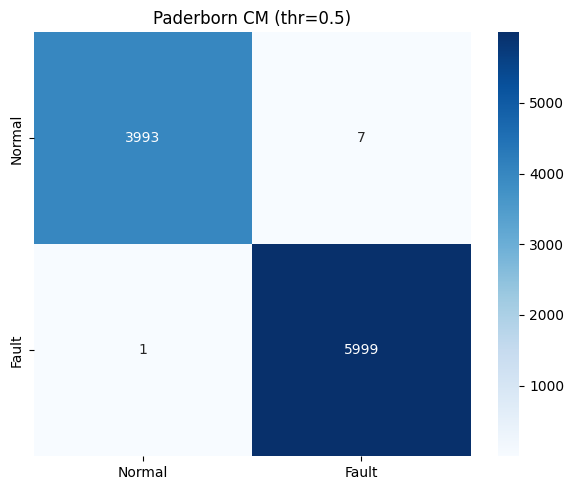

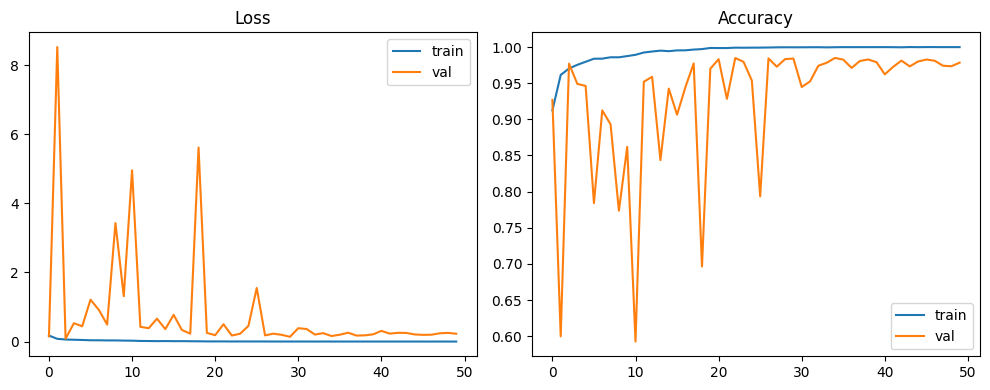


[Test 베어링별 결과]
코드       라벨     샘플     FNR%     FAR%    
K006     Normal   4000     0.00     0.18
KA01     Fault    2000     0.05     0.00
KA15     Fault    2000     0.00     0.00
KI03     Fault    2000     0.00     0.00


In [ ]:
# ============================================================
# 셀 6. ★ E1 수정: Test 전체로 최종 KPI 평가
# ============================================================
import seaborn as sns
from sklearn.metrics import classification_report

# Test 전체 평가 (n_eval 제한 없음)
prob_te = model.predict(X_te, batch_size=128, verbose=0).ravel()
pred_te = (prob_te >= best_thr).astype(int)

acc = accuracy_score(y_te, pred_te)
mf1 = f1_score(y_te, pred_te, average='macro')
cm  = confusion_matrix(y_te, pred_te)
tn, fp, fn, tp = cm.ravel()
fnr = fn/(fn+tp)*100 if (fn+tp) else 0
far = fp/(fp+tn)*100 if (fp+tn) else 0

print('=' * 60)
print(f'  Paderborn KPI — Test 전체 평가 (thr={best_thr})')
print('=' * 60)
print(f'  Accuracy  : {acc*100:6.2f}%   (목표 >= 98%)')
print(f'  Macro F1  : {mf1*100:6.2f}%   (목표 >= 97%)')
print(f'  FNR (미탐): {fnr:6.2f}%   (목표 < 2%)')
print(f'  FAR (오경보): {far:6.2f}%  (목표 < 1%)')
ok = acc >= 0.98 and fnr < 2.0 and far < 1.0
print(f'  판정: {"KPI 달성" if ok else "KPI 미달"}')
print('=' * 60)
print(classification_report(y_te, pred_te, target_names=CLASS_NAMES))

# Confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'Paderborn CM (thr={best_thr})')
plt.tight_layout()
plt.savefig('confusion_paderborn.png', dpi=150)
plt.show()

# 학습 곡선
plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss'); plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy'); plt.legend()
plt.tight_layout()
plt.savefig('training_curve_paderborn.png', dpi=150)
plt.show()

# ★ 베어링별 FNR 분석
print('\n[Test 베어링별 결과]')
bc_te = bearing_codes[te_mask]
print(f'{"코드":8} {"라벨":6} {"샘플":6} {"FNR%":8} {"FAR%":8}')
for code in sorted(np.unique(bc_te)):
    m = bc_te == code
    y_c = y_te[m]; p_c = pred_te[m]
    c_m = confusion_matrix(y_c, p_c, labels=[0,1])
    t,f = (c_m[1,0]/(c_m[1,:].sum())*100 if c_m[1,:].sum() else 0,
           c_m[0,1]/(c_m[0,:].sum())*100 if c_m[0,:].sum() else 0)
    lbl = 'Normal' if code.startswith('K0') else 'Fault'
    print(f'{code:8} {lbl:6} {m.sum():6} {t:8.2f} {f:8.2f}')

In [ ]:
# ============================================================
# 셀 7. TFLite INT8 변환
# ============================================================
import tensorflow as tf

def representative_dataset():
    idx = np.random.choice(len(X_tr), min(500, len(X_tr)), replace=False)
    for i in idx:
        yield [X_tr[i:i+1].astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations              = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset    = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type      = tf.int8
converter.inference_output_type     = tf.int8

print('TFLite INT8 변환 중...')
tflite_model = converter.convert()

TFLITE_PATH = 'paderborn_int8.tflite'
with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)

interp = tf.lite.Interpreter(model_content=tflite_model)
interp.allocate_tensors()
inp_det = interp.get_input_details()[0]
out_det = interp.get_output_details()[0]
inp_scale, inp_zp = inp_det['quantization']
out_scale, out_zp = out_det['quantization']

print(f'저장: {TFLITE_PATH}  ({len(tflite_model)/1024:.1f} KB)')
print(f'Input  scale={inp_scale:.8f}, zero_point={inp_zp}')
print(f'Output scale={out_scale:.8f}, zero_point={out_zp}')

TFLite INT8 변환 중...
Saved artifact at '/tmp/tmpw6nxcit4'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 4096, 1), dtype=tf.float32, name='vibration_input')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135779357253008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135779357253968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135779357255312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135779357253392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135779357253200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135779357256272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135779357256464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135779357256656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135779357254544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135779357255888: TensorSpec(shape=(), dtype=tf.resource, name=Non

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


저장: paderborn_int8.tflite  (255.5 KB)
Input  scale=0.00524592, zero_point=-4
Output scale=0.00390625, zero_point=-128


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
# ============================================================
# 셀 8. 양자화 검증 (Test 전체) + 헤더 + Drive 저장
# ============================================================
import shutil
from sklearn.metrics import accuracy_score

# ★ E1 수정: Test 전체로 TFLite 평가 (500개 제한 제거)
# 시간이 오래 걸리면 1000개로 제한 (층화 추출)
n_eval = len(X_te)
print(f'TFLite 검증: {n_eval}개 전체 평가 중...')

tflite_preds = []
for i in range(n_eval):
    x_q = np.clip(np.round(X_te[i:i+1] / inp_scale + inp_zp), -128, 127).astype(np.int8)
    interp.set_tensor(inp_det['index'], x_q)
    interp.invoke()
    out = interp.get_tensor(out_det['index'])
    tflite_preds.append(int(out.ravel()[0] > 0) if PHASE == 'A' else int(out.argmax()))
    if (i+1) % 500 == 0:
        print(f'  {i+1}/{n_eval}...')

keras_raw   = model.predict(X_te, batch_size=128, verbose=0)
keras_preds = (keras_raw.ravel() >= best_thr).astype(int).tolist() if PHASE == 'A' else keras_raw.argmax(axis=1).tolist()

match_rate = np.mean(np.array(tflite_preds) == np.array(keras_preds)) * 100
tflite_acc = accuracy_score(y_te, tflite_preds) * 100
tflite_cm  = confusion_matrix(y_te, tflite_preds)
if tflite_cm.size >= 4:
    tn2, fp2, fn2, tp2 = tflite_cm.ravel()
    t_fnr = fn2/(fn2+tp2)*100 if (fn2+tp2) else 0
    t_far = fp2/(fp2+tn2)*100 if (fp2+tn2) else 0
    print(f'TFLite FNR: {t_fnr:.2f}%, FAR: {t_far:.2f}%')

print(f'Argmax 일치율 : {match_rate:.2f}%  (목표 100%)')
print(f'TFLite 정확도 : {tflite_acc:.2f}%')

# 펌웨어 헤더
header = f"""/**
 * AI 김반장 LITE - Paderborn 모델 상수 v3 (자동 생성)
 * Window: {WINDOW} samples @ 64kHz = {WINDOW/64000*1000:.1f}ms
 * Train-only normalization
 */
#ifndef AI_KIM_BANJANG_PADERBORN_H
#define AI_KIM_BANJANG_PADERBORN_H
#define AI_WINDOW_SIZE        {WINDOW}U
#define AI_SAMPLE_RATE        64000U
#define AI_SCALE_MIN          {SCALE_MIN:.6f}f
#define AI_SCALE_MAX          {SCALE_MAX:.6f}f
#define AI_INPUT_SCALE        {inp_scale:.8f}f
#define AI_INPUT_ZERO_POINT   ({int(inp_zp)})
#define AI_OUTPUT_SCALE       {out_scale:.8f}f
#define AI_OUTPUT_ZERO_POINT  ({int(out_zp)})
#define AI_FAULT_THRESHOLD    {best_thr:.2f}f
#endif
"""
with open('paderborn_constants.h', 'w') as f:
    f.write(header)

SAVE_DIR = '/content/drive/MyDrive/Colab Notebooks/AI_KimBanjang_Paderborn'
os.makedirs(SAVE_DIR, exist_ok=True)
for fname in ['best_paderborn.keras', 'paderborn_int8.tflite',
               'paderborn_constants.h', 'confusion_paderborn.png',
               'training_curve_paderborn.png']:
    if os.path.exists(fname):
        shutil.copy(fname, os.path.join(SAVE_DIR, fname))
        print(f'  저장: {fname}')

print('\n완료!')

TFLite 검증: 10000개 전체 평가 중...
  500/10000...
  1000/10000...
  1500/10000...
  2000/10000...
  2500/10000...
  3000/10000...
  3500/10000...
  4000/10000...
  4500/10000...
  5000/10000...
  5500/10000...
  6000/10000...
  6500/10000...
  7000/10000...
  7500/10000...
  8000/10000...
  8500/10000...
  9000/10000...
  9500/10000...
  10000/10000...
TFLite FNR: 0.00%, FAR: 0.18%
Argmax 일치율 : 99.97%  (목표 100%)
TFLite 정확도 : 99.93%
  저장: best_paderborn.keras
  저장: paderborn_int8.tflite
  저장: paderborn_constants.h
  저장: confusion_paderborn.png
  저장: training_curve_paderborn.png

완료!
